<a href="https://colab.research.google.com/github/DmitriySutyagin/-/blob/master/LR_1_4_Sutyagin_ET_212.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Импорт библиотек.

In [77]:
import numpy as np
import matplotlib.pyplot as plt


# **Блок 1. NumPy и векторизованная обработка данных**

## Задание 1.1. Базовые свойства массивов

### Создание массивов.

In [78]:
delivery_time = np.array([35, 42, 28, 51, 39, 63, 31, 45])
order_price = np.array([1200, 3500, 800, 4200, 1900, 5600,1500, 2800])
items_count = np.array([2, 5, 1, 7, 3, 8, 2, 4])

Для каждого массива вывод:  
◦ shape;  
◦ ndim;  
◦ size.

In [79]:
print(f"shape delivery_time равен: {delivery_time.shape}")
print(f"ndim delivery_time равен: {delivery_time.ndim}")
print(f"size delivery_time равен: {delivery_time.size}")

shape delivery_time равен: (8,)
ndim delivery_time равен: 1
size delivery_time равен: 8


In [80]:
print(f"shape order_price равен: {order_price.shape}")
print(f"ndim order_price равен: {order_price.ndim}")
print(f"size order_price равен: {order_price.size}")

shape order_price равен: (8,)
ndim order_price равен: 1
size order_price равен: 8


In [81]:
print(f"shape items_count равен: {items_count.shape}")
print(f"ndim items_count равен: {items_count.ndim}")
print(f"size items_count равен: {items_count.size}")

shape items_count равен: (8,)
ndim items_count равен: 1
size items_count равен: 8


В контексте массивов NumPy (np.array) атрибут size возвращает общее количество элементов в массиве.

Проще говоря, это число показывает, сколько элементов (чисел, строк, других объектов) хранится внутри массива, независимо от того, сколько у него измерений (строк, столбцов, каналов и т.д.).

### Проверка с помощью Python, что все три массива содержат одинаковое количество наблюдений.

In [82]:
if len(delivery_time) == len(order_price ) == len(items_count ):
 print("Все массивы содержат одинаковое количество наблюдений.")
else:
 print("Количество наблюдений в массивах разное.")

Все массивы содержат одинаковое количество наблюдений.


Короткий вывод: индексы в массивах delivery_time, order_price и items_count должны строго соответствовать одному и тому же заказу — так обеспечивается правильная связь данных.

## **Вопрос для анализа**

При подсчете средней цены заказа, опираясь только на совпадающие индексы, мы фактически потеряем часть данных (один заказ «выпадет»). Или, пытаясь выровнять массивы «на глаз» (например, отбросив последний элемент), мы случайно сопоставим данные разных заказов — и тогда расчёт будет абсолютно бессмысленным.

## **Задание 1.2. Двумерные массивы**

Объедините данные в единую матрицу orders.
Каждая строка должна соответствовать одному заказу, а столбцы должны содержать:
1. время доставки;
2. стоимость заказа;
3. количество товаров.  
Создание матрицы:

In [83]:
orders = np.array([
 [35, 1200, 2],
 [42, 3500, 5],
 [28, 800, 1],
 [51, 4200, 7],
 [39, 1900, 3],
 [63, 5600, 8],
 [31, 1500, 2],
 [45, 2800, 4]
])

### Вывод orders.shape.

In [84]:
orders.shape

(8, 3)

С помощью индексации получаем:  
◦ данные первого заказа;  
◦ время доставки всех заказов;  
◦ стоимость всех заказов;  
◦ количество товаров в шестом заказе.

In [85]:
# данные первого заказа
orders[1]

array([  42, 3500,    5])

In [86]:
# время доставки всех заказов;
orders[:,-1]

array([2, 5, 1, 7, 3, 8, 2, 4])

In [87]:
# стоимость всех заказов
orders[:, -2]

array([1200, 3500,  800, 4200, 1900, 5600, 1500, 2800])

In [88]:
#  количество товаров в шестом заказе.
orders[4][2]

np.int64(3)

## **Вопрос для анализа**

orders.shape
возвращает кортеж (8, 3) потому что в матрице orders содержится 8 заказов (массивов) из 3 признаков время доставки, стоимость заказа, количество товаров.

orders.size возвращает 24. Так как метод size возвращает количество элементов в матрице.

## **Задание 1.3. View и Copy**

###Выделение из матрицы orders столбеца времени доставки:

In [89]:
delivery = orders[:, 0]
delivery

array([35, 42, 28, 51, 39, 63, 31, 45])

### Измение первого элемента delivery на 1000.

In [90]:
delivery[0] = 1000
delivery

array([1000,   42,   28,   51,   39,   63,   31,   45])

### Вывод матрицы orders

In [91]:
orders

array([[1000, 1200,    2],
       [  42, 3500,    5],
       [  28,  800,    1],
       [  51, 4200,    7],
       [  39, 1900,    3],
       [  63, 5600,    8],
       [  31, 1500,    2],
       [  45, 2800,    4]])

delivery — это как «окно» в исходный массив orders. Когда вы меняете значение через это окно, вы фактически меняете данные в самом orders.

### Восстановление исходной матрицы orders.

In [92]:
orders[0][0] = 35
orders

array([[  35, 1200,    2],
       [  42, 3500,    5],
       [  28,  800,    1],
       [  51, 4200,    7],
       [  39, 1900,    3],
       [  63, 5600,    8],
       [  31, 1500,    2],
       [  45, 2800,    4]])

### Создание независимой копии:

In [93]:
delivery_copy = orders[:, 0].copy()
delivery_copy

array([35, 42, 28, 51, 39, 63, 31, 45])

### Измениние первого элемента delivery_copy.

In [94]:
delivery_copy[0] = 1000
delivery_copy

array([1000,   42,   28,   51,   39,   63,   31,   45])

### Вывод матрицы orders.

In [95]:
orders

array([[  35, 1200,    2],
       [  42, 3500,    5],
       [  28,  800,    1],
       [  51, 4200,    7],
       [  39, 1900,    3],
       [  63, 5600,    8],
       [  31, 1500,    2],
       [  45, 2800,    4]])

### Сравнение результатов двух экспериментов.

Исходная матрица осталась не изменна,потому что была измена копия исходной матрицы.

## **Вопросы для анализа**

Почему понимание различия между view и copy важно при обработке реальных наборов
данных?

При обработке реальных наборов данных важно понимание различия между view и copy, потому что при работе  представлением view можно испортить исходные данные, что в дельнейшем повлияет на качество обученной модели.


Приведите пример ситуации, в которой случайное изменение view может привести к ошибке в дальнейшем анализе.

Удаление данных, изменние данных, не правльное слияние массивов.

## **Задание 1.4. Фильтрация с помощью булевых масок**

## Создание массива времени доставки заказов.

In [96]:
delivery_time = np.array([35, 42, 28, 51, 39, 63, 31, 45])
delivery_time

array([35, 42, 28, 51, 39, 63, 31, 45])

## Создание булевой маски для поиска заказов с временем доставки больше 45 минут.

In [97]:
problem = delivery_time[delivery_time > 45]
problem

array([51, 63])

## Подсчет проблемных заказов

In [98]:
print(f"Количество проблемных заказов: {problem.size}")

Количество проблемных заказов: 2


## Рассчет среднего времи доставки для этой группы.

In [99]:
mean_time = np.mean(delivery_time)
print(f"Время среднего времи доставки для этой группы: {mean_time}")

Время среднего времи доставки для этой группы: 41.75


## **Вопрос для анализа**  
В чём различие между условиями:  
delivery_time > 45  
и  
delivery_time >= 45  
Как изменение граничного условия может повлиять на бизнес-метрику?

В маске delivery_time >= 45 значение 45 включается в фильтр, а при маске delivery_time > 45 не включается.    
Изменение граничного условия может заметно сдвинуть ключевые показатели.

## **Задание 1.5. Фильтрация по нескольким условиям**


Менеджер продукта хочет изучить заказы, которые одновременно являются крупными по
стоимости и содержат большое количество товаров.  
Критерии:  
• стоимость заказа больше 3000 рублей;  
• количество товаров больше 4.

### Создание единой булевой маски, учитывающая оба условия.

In [100]:
maska_orders = orders[(orders[:, -2] > 3000) & (orders[:, -1] > 4)]
maska_orders

array([[  42, 3500,    5],
       [  51, 4200,    7],
       [  63, 5600,    8]])

### Получение стоимости подходящих заказов.


In [101]:
maska_orders[:, -2]

array([3500, 4200, 5600])

### Получение времи доставки этих заказов.


In [102]:
maska_orders[:, -3]

array([42, 51, 63])

### Расчет среднего времи доставки выбранной группы.

In [103]:
print(f"Среднее время доставки выбранной группы: {np.mean(maska_orders[:, -3])}")

Среднее время доставки выбранной группы: 52.0


## **Вопрос для анализа**  
Почему анализ комбинации нескольких признаков может дать более полезный результат для бизнеса, чем анализ каждого признака отдельно?  

Потому что при рассмотрении комбинации из нескольких признков видно полностью сложившиюся ситуацию по времени доставки, прибыли, количеству товаров.  

Приведите пример ситуации, когда отдельный показатель выглядит нормально, но комбинация нескольких признаков выявляет проблему.  

При отимальном времени доставки цена может быть ниже среднего что повлияет на прибыль.


# **Блок 2. Описательная статистика**

## **Задание 2.1. Влияние выбросов на статистические показатели**

### Создание массива времи доставки пяти заказов:

In [104]:
delivery_time = np.array([8, 9, 10, 11, 12])

### Рассчет среднеарифмитического и мадианны массива delivery_time

In [105]:
print(f"Средне арифметическое массива delivery_time: {np.mean(delivery_time)}")
print(f"Медина массива delivery_time: {np.median(delivery_time)}")

Средне арифметическое массива delivery_time: 10.0
Медина массива delivery_time: 10.0


### Добавление в выборку одного аномального результата — доставку продолжительностью 1000 минут.

In [106]:
delivery_time_corrupted = np.array([8, 9, 10, 11, 12, 1000])
delivery_time_corrupted

array([   8,    9,   10,   11,   12, 1000])

### Повторный рассчет среднего и медианы

In [107]:
print(f"Средне арифметическое массива delivery_time_corrupted: {np.mean(delivery_time_corrupted)}")
print(f"Медина массива delivery_time_corrupted: {np.median(delivery_time_corrupted)}")

Средне арифметическое массива delivery_time_corrupted: 175.0
Медина массива delivery_time_corrupted: 10.5


### Сравнение результата до и после появления выброса.

После появления выброса среднеарифмитическое значение увеличилось в 17.5 раз. А медиана всего на 0.5. Это показывает,что среднеарифмитическое зависимо от аномальных значений и оказывает существенное влияни на безнесс - метрики.

## **Вопросы для анализа**
Почему среднее так сильно изменилось?  

Среднее изменилось потому, что сумма всех значений увеличилось в 20 раз, а количество элементов всего на 1.

Почему медиана изменилась значительно меньше?  
Потому что медиана высчитывает как центральное значение в массиве.


Какой показатель лучше описывает типичное время доставки при наличии редких
экстремальных значений?  
Показатель медианны лучше описывает типичное время доставки при наличии редких экстремальных значений. Потому что при обучение модели используя искаженное среднеарифмитическое значение обученная модель будет предсказывать не правливые метрики что повлияется на стоимость и время доставки товара.

## **Задание 2.2. Процентили и SLA**

## Для проверки SLA смоделируйте 1000 наблюдений времени доставки.

In [108]:
np.random.seed(42)
delivery_simulated = np.random.normal(
 loc=30,
 scale=5,
 size=1000
)
delivery_simulated

array([32.48357077, 29.30867849, 33.23844269, 37.61514928, 28.82923313,
       28.82931522, 37.89606408, 33.83717365, 27.65262807, 32.71280022,
       27.68291154, 27.67135123, 31.20981136, 20.43359878, 21.37541084,
       27.18856235, 24.9358444 , 31.57123666, 25.45987962, 22.93848149,
       37.32824384, 28.8711185 , 30.33764102, 22.87625907, 27.27808638,
       30.55461295, 24.24503211, 31.87849009, 26.99680655, 28.54153125,
       26.99146694, 39.26139092, 29.93251388, 24.71144536, 34.11272456,
       23.89578175, 31.04431798, 20.20164938, 23.35906976, 30.98430618,
       33.6923329 , 30.85684141, 29.42175859, 28.49448152, 22.60739005,
       26.40077896, 27.69680615, 35.28561113, 31.71809145, 21.18479922,
       31.62041985, 28.0745886 , 26.61539   , 33.05838144, 35.15499761,
       34.6564006 , 25.80391238, 28.45393812, 31.65631716, 34.87772564,
       27.60412881, 29.07170512, 24.46832513, 24.01896688, 34.06262911,
       36.78120014, 29.63994939, 35.01766449, 31.80818013, 26.77

## Расчет:  
◦ среднее значение;  
◦ стандартное отклонение;  
◦ медиану.

In [109]:
print(f"Средне арифметическое массива delivery_simulated: {np.mean(delivery_simulated)}")
print(f"Стандартное отклонение массива delivery_simulated: {np.std(delivery_simulated)}")
print(f"Медина массива delivery_simulated: {np.median(delivery_simulated)}")

Средне арифметическое массива delivery_simulated: 30.096660279111628
Стандартное отклонение массива delivery_simulated: 4.893631038736771
Медина массива delivery_simulated: 30.12650306117444


## Рассчет процентилей.

In [110]:
qv_50 = np.quantile(delivery_simulated, 0.5)
print(f"Пятидесятый квантиль равен: {qv_50}")
qv_90 = np.quantile(delivery_simulated, 0.9)
print(f"Девяностый квантиль равен: {qv_90}")
qv_95 = np.quantile(delivery_simulated, 0.95)
print(f"Девяностопятый квантиль равен: {qv_95}")
qv_99 = np.quantile(delivery_simulated, 0.99)
print(f"Девяностодевятый квантиль равен: {qv_99}")

Пятидесятый квантиль равен: 30.12650306117444
Девяностый квантиль равен: 36.52822600933569
Девяностопятый квантиль равен: 38.38486264207573
Девяностодевятый квантиль равен: 41.57984750401471


### Сравнение полученных значения с параметрами, использованными при генерации данных.

Полученные значения соответвуют параметрам  использованным при генераци данных

### Определение p90, проверка выполняется ли заявленный SLA.

In [111]:
time_q90 = np.quantile(delivery_simulated[: -2], 0.9)
print(f"Время доставки товара для 90% заказов: {time_q90}")

Время доставки товара для 90% заказов: 36.52988995646379


In [112]:
print(f"SLA выполняется, потому что time_q90 равен: {np.round(time_q90, 2)} минут меньше чем 40 минут")

SLA выполняется, потому что time_q90 равен: 36.53 минут меньше чем 40 минут


## **Вопросы для анализа**
Что означает p90 для времени доставки?  
p90 для времени доставки означает, что все значения меньше  36.53 минут.

Что означает p95?  
p95 для времени доставки означает, что все значения меньше  38.38
минут.



Почему для распределения времени доставки p95 обычно выше p90?
Потому что чем левее значение находиться в выборке тем оно меньше

Что изменится в управлении логистикой, если компания начнёт ориентироваться не только на p90, но и на p95?  
Умньшится количество проблемных заказов.

## **Продуктовый вывод**
Сформулируйте вывод для менеджера продукта в 2–3 предложениях:  
• выполняется ли SLA;  
• насколько хорошо контролируется длинный хвост распределения.

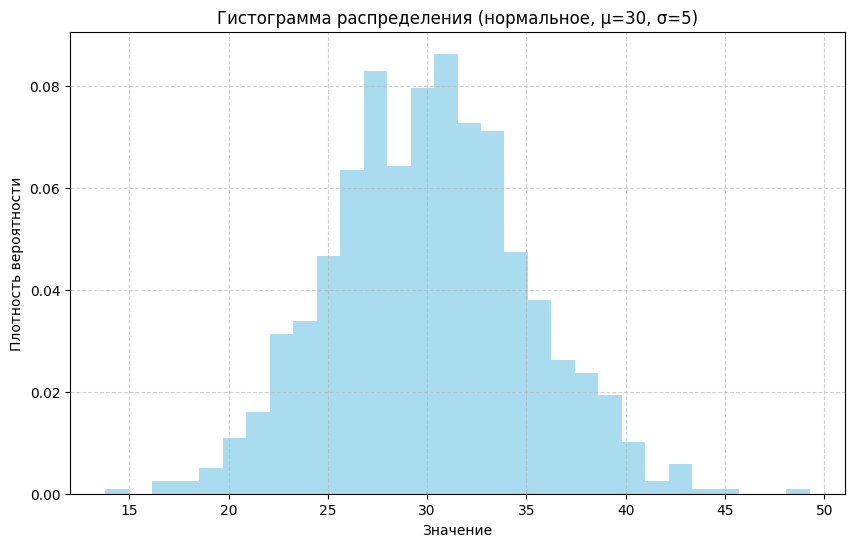

In [113]:
# Ваш код с генерацией
np.random.seed(42)
delivery_simulated = np.random.normal(loc=30, scale=5, size=1000)

# Построение гистограммы
plt.figure(figsize=(10, 6))
plt.hist(delivery_simulated, bins=30, alpha=0.7, color='skyblue', density=True)
plt.title('Гистограмма распределения (нормальное, μ=30, σ=5)')
plt.xlabel('Значение')
plt.ylabel('Плотность вероятности')
plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.show()


SLA выполняется, потому что time_q90 равен: 36.53 минут меньше чем 40 минут.Дляинные хвосты хорошо контролируются потому что в них нет аномальных значений.

## **Задание 2.3. Разброс и предсказуемость**

###  Две курьерские службы выполнили по пять одинаковых доставок.

In [114]:
service_A = np.array([28, 29, 30, 31, 32])
service_B = np.array([15, 20, 30, 40, 45])

### Расчет для service_A

In [115]:
print(f"Средне значение для пяти дотавок service_A: {np.mean(service_A)}")
print(f"Медиана значений для пяти дотавок service_A: {np.median(service_A)}")
print(f"Стандартное отклонние значений для пяти дотавок service_A: {np.std(service_A, ddof=0)}")
print(f"Девяностый квантиль равен: {np.quantile(service_A, 0.9)}")

Средне значение для пяти дотавок service_A: 30.0
Медиана значений для пяти дотавок service_A: 30.0
Стандартное отклонние значений для пяти дотавок service_A: 1.4142135623730951
Девяностый квантиль равен: 31.6


### Расчет для service_B

In [116]:
print(f"Средне значение для пяти дотавок service_B: {np.mean(service_B)}")
print(f"Медиана значений для пяти дотавок service_B: {np.median(service_B)}")
print(f"Стандартное отклонние значений для пяти дотавок service_B: {np.std(service_B, ddof=0)}")
print(f"Девяностый квантиль равен: {np.quantile(service_B, 0.9)}")

Средне значение для пяти дотавок service_B: 30.0
Медиана значений для пяти дотавок service_B: 30.0
Стандартное отклонние значений для пяти дотавок service_B: 11.40175425099138
Девяностый квантиль равен: 43.0


## **Вопросы для анализа**  
Почему одинаковые или близкие средние значения не означают одинаковое качество
работы?

Потому что распределение не равномерное

Какая служба является более предсказуемой?  
service_A явлеется более предсказуемым

Какую службу вы выбрали бы для доставки дорогой электроники?  
Первую службу

Какие статистические показатели повлияли бы на ваше решение?  
Время и качество доставки.

## **Задание 2.4. Корреляция**

### Генерация данных.


In [117]:
np.random.seed(42)
items = np.random.randint(1, 10, 100)
delivery_time_correlated = (20 + 3 * items + np.random.normal(0, 3, 100))

Вывод значений items

In [118]:
items

array([7, 4, 8, 5, 7, 3, 7, 8, 5, 4, 8, 8, 3, 6, 5, 2, 8, 6, 2, 5, 1, 6,
       9, 1, 3, 7, 4, 9, 3, 5, 3, 7, 5, 9, 7, 2, 4, 9, 2, 9, 5, 2, 4, 7,
       8, 3, 1, 4, 2, 8, 4, 2, 6, 6, 4, 6, 2, 2, 4, 8, 7, 9, 8, 5, 2, 5,
       8, 9, 9, 1, 9, 7, 9, 8, 1, 8, 8, 3, 1, 8, 3, 3, 1, 5, 7, 9, 7, 9,
       8, 2, 1, 7, 7, 8, 5, 3, 8, 6, 3, 1])

Вывод значений delivery_time_correlated

In [119]:
delivery_time_correlated

array([41.98053567, 31.75664314, 45.40338426, 37.20836705, 38.66089436,
       26.46831092, 40.54839843, 41.10332698, 35.45146723, 31.65973625,
       51.90058466, 40.92472733, 26.65385652, 39.27182921, 37.61811529,
       32.86167795, 48.8687615 , 40.47119923, 26.87917774, 37.68989115,
       21.16903395, 37.05150231, 42.55272726, 22.31345745, 31.88792387,
       40.37092269, 29.67787121, 45.92066556, 31.17224975, 34.23270609,
       31.54976361, 37.06602732, 32.38908514, 45.48007034, 37.07014794,
       34.83099025, 28.71120261, 49.74465297, 24.00181814, 45.45863753,
       35.9039684 , 21.62444924, 30.01178506, 40.56058158, 41.46194895,
       26.53253189, 26.26018107, 35.01496064, 24.67470193, 43.74750474,
       35.71104822, 21.72056335, 39.01406798, 43.92371359, 37.89510429,
       32.18026634, 23.71211911, 26.50597816, 28.03436915, 41.9952599 ,
       40.58812699, 51.20396469, 43.86379203, 35.65081018, 27.5372712 ,
       36.63046607, 44.08429839, 43.40873881, 49.36901841, 24.29

### Расчет коэффициента корреляции Пирсона между items и delivery_time_correlated с помощью np.corrcoef().

In [120]:
print(f"Корреляция Пирсона между items и delivery_time_correlated с помощью np.corrcoef(): \n{np.corrcoef(items, delivery_time_correlated)}")

Корреляция Пирсона между items и delivery_time_correlated с помощью np.corrcoef(): 
[[1.         0.93432937]
 [0.93432937 1.        ]]


Извлечение коэффициента r.


In [121]:
r = np.corrcoef(items, delivery_time_correlated)[0, 1]
print(f"Коэффицент r: {np.round(r, 2)}")

Коэффицент r: 0.93


Направление: положительное. Это значит, что с ростом количества товаров в заказе время доставки в среднем увеличивается.
Сила линейной связи: очень сильная. По общепринятой шкале (например, шкале Чеддока), значения ∣𝑟∣>0.7 считаются сильной связью, а ∣𝑟∣>0.9 — очень сильной. Здесь 𝑟≈0.93, что говорит о тесной линейной зависимости.

### Объяснение наблюдаемой зависимости с точки зрения работы склада и доставки.

**Комплектация заказа.** Чем больше товаров, тем больше времени требуется сборщику, чтобы найти все позиции на складе, проверить их качество и упаковать.  
**Проверка и контроль.** Крупные заказы чаще требуют дополнительной проверки (вес, габариты, комплектность), чтобы избежать ошибок.  
**Упаковка и подготовка к отгрузке.** Большие заказы могут требовать иной упаковки (коробки большего размера, обрешётка) или специальной маркировки, что увеличивает время обработки.  
**Логистика.** Заказ с большим количеством товаров может требовать другого типа транспорта или отдельного рейса, либо занимать больше места при погрузке, что влияет на общее время доставки.

**Вопрос для анализа**  
Можно ли на основании высокого значения корреляции утверждать:  
«Увеличение количества товаров является причиной увеличения времени доставки»?  


Корреляция не причинность.   
Корреляция лишь показывает, что две переменные изменяются согласованно. Это не означает, что одна вызывает другую.

## **Задание 2.5. Корреляция и скрытые факторы**  
Рассмотрим ситуацию:  
Летом одновременно увеличиваются:  
• продажи мороженого;  
• количество несчастных случаев на воде.  
На основании этих данных аналитик делает вывод:  
«Продажа мороженого приводит к увеличению количества несчастных случаев на воде».  
Что необходимо сделать  
1. Объясните, почему высокая корреляция не доказывает наличие причинно-следственной связи.  
2. Определите фактор, который может влиять одновременно на оба показателя.  
3. Объясните механизм возникновения наблюдаемой корреляции.  
4. Приведите собственный пример ложной корреляции из бизнеса, технологий, медиа илиповседневной жизни.:

Высокая корреляция продажи мороженного и несчастные случаи на воде не могут корррелировать. Высокая корреляция происходит только с высокой температурой воздука.  
Пример из бизнеса: компания заметила, что в течение года расходы на маркетинг и выручка растут синхронно: когда бюджет на продвижение увеличивается, продажи тоже идут вверх. На первый взгляд, это доказывает: маркетинг напрямую увеличивает продажи.
Но на деле это ложная корреляция. Обе переменные на самом деле движутся под влиянием общего скрытого фактора — сезонности. Компания просто увеличивает траты на рекламу именно в те периоды, когда спрос и так высокий (например, перед праздниками или летом). Таким образом, корреляция возникает не потому, что маркетинг работает, а из-за того, что обе метрики реагируют на один и тот же сезонный цикл


#**Блок 3. Bootstrap и статистическиегипотезы**

## **Задание 3.1. Bootstrap и доверительный интервал**

### Создание массива измерений времени сборки шести заказов.

In [134]:
x = np.array([28, 31, 29, 45, 32, 30])
x

array([28, 31, 29, 45, 32, 30])

Рассчет среднего значения исходной выборки.
2. Реализация Bootstrap с количеством итераций:
B = 5000
На каждой итерации:
• вормируется выборка такого же размера, как x;
• используется выборка с возвращением;
• рассчитывается её среднее;
• сохраняется результат.
Для формирования Bootstrap-выборки используется:
np.random.choice()

In [129]:
# Исходные данные
x = np.array([28, 31, 29, 45, 32, 30])

# Количество итераций бутстрэпа
B = 5000

# Размер выборки (такой же, как у x)
n = len(x)

# Массив для хранения средних значений бутстрэп-выборок
bootstrap_means = np.zeros(B)

# Цикл бутстрэпа
for i in range(B):
    # Выборка с возвращением того же размера, что и x
    bootstrap_sample = np.random.choice(x, size=n, replace=True)
    # Считаем среднее для этой выборки
    bootstrap_means[i] = bootstrap_sample.mean()

# Среднее бутстрэп-распределения (для справки)
bootstrap_mean_overall = bootstrap_means.mean()


print(f"Среднее исходной выборки: {x.mean():.2f}")
# print(f"Сгенерированая выборка: {bootstrap_sample}")
print(f"Среднее бутстрэп-распределения: {bootstrap_mean_overall:.2f}")


Среднее исходной выборки: 32.50
Среднее бутстрэп-распределения: 32.50
95% доверительный интервал для среднего: [29.17, 37.67]


Получение центрального 95%-го доверительного интервала для среднего с помощью:
np.quantile()
Используйте квантили:
0.025
0.975
Вывод полученного доверительного интервала.

In [133]:
# 95% доверительный интервал
ci_lower, ci_upper = np.quantile(bootstrap_means, [0.25, 0.975])

print(f"95% доверительный интервал для среднего: [{ci_lower:.2f}, {ci_upper:.2f}]")

95% доверительный интервал для среднего: [30.33, 37.67]


## **Вопросы для анализа**  
Почему Bootstrap используется именно с выборкой с возвращением?  

Суть бутстрэпа — оценить, как статистика (среднее, медиана, коэффициент регрессии и т. п.) ведёт себя при разных выборках из той же генеральной совокупности, когда у нас есть только одна реальная выборка. Мы используем её как «приближение» к генеральной совокупности.


Как наличие наблюдения 45 влияет на Bootstrap-распределение среднего?  

Увеличивает дисперсию бутстреп‑распределения среднего.
В бутстреп‑средних появляются «тяжёлые хвосты» вправо: бывают выборки, где 45 встречается 2–3 раза, и среднее уходит к 35+. Без 45 разброс средних был бы гораздо меньше.  

Смещает форму распределения: оно становится асимметричным (скошенным вправо).  
Без выброса распределение средних было бы почти симметричным из‑за ЦПТ даже при малом n. С 45 распределение имеет длинный правый хвост.  

Расширяет доверительные интервалы.  
Из‑за большей изменчивости перцентильные ДИ (например, 2.5% и 97.5%) будут существенно шире.

Почему результаты Bootstrap могут заметно изменяться при использовании очень маленькой исходной выборки?  

Главная причина: мало уникальных комбинаций
Бутстреп делает выборки с возвращением из исходных данных. Число возможных различных бутстреп‑выборок размера n из n элементов — это число мультимножеств, оно растёт не экспоненциально, а как полином от n. Для n=6 пространство всех возможных выборок довольно маленькое. Это значит, что даже при 5 000 итераций фактически «перебирается» большая часть возможных комбинаций, и случайные флуктуации между запусками сильнее заметны.



Можно ли утверждать:
«Вероятность того, что истинное среднее находится внутри рассчитанного 95%-го доверительного интервала, равна 95%»?  

Нет, так утверждать нельзя. Это распространённое заблуждение.

Суть в том, что в классической (частотной) статистике истинное среднее — это фиксированная, хотя и неизвестная величина. Оно либо попадает в рассчитанный вами конкретный интервал, либо нет. Для этого одного интервала вероятность не определяется: она либо 1 (попадает), либо 0 (не попадает).  

Что же тогда означает «95%»? Эта цифра характеризует процедуру построения интервала, а не конкретный результат. Правильная формулировка такая: если многократно повторять эксперимент (брать новые выборки, каждый раз строить интервал по той же методике), то примерно в 95% таких интервалов истинное среднее действительно окажется внутри. В оставшихся 5% интервал его не захватит.  

Проще говоря: 95% — это долгосрочная частота «попаданий» метода, а не вероятность для одной конкретной выборки.


## **Задание 3.2. Формулировка гипотез и ошибки I и II рода**

## 1. Нулевая гипотеза $H_0$

$H_0: \mu_A = \mu_B$ — истинное среднее время доставки в контрольной группе и в группе с новым алгоритмом одинаково. Иными словами, новый алгоритм **не даёт эффекта**: он не уменьшает среднее время доставки.

---

## 2. Альтернативная гипотеза $H_1$

$H_1: \mu_A > \mu_B$ — среднее время доставки в группе с новым алгоритмом **меньше**, чем в контрольной группе.

---

## 3. Что означают ошибки I и II рода в этом эксперименте

- **Ошибка I рода** — это отклонение верной нулевой гипотезы: мы делаем вывод, что новый алгоритм уменьшает время доставки ($\mu_B < \mu_A$), хотя на самом деле он **не работает** (реального эффекта нет).  
  В терминах эксперимента: данные «случайно» показали улучшение, и мы принимаем решение внедрять алгоритм, хотя он не приносит пользы.

- **Ошибка II рода** — это принятие неверной нулевой гипотезы: алгоритм на самом деле уменьшает время доставки, но по данным эксперимента мы **не смогли это обнаружить** и делаем вывод, что эффекта нет.  
  В терминах эксперимента: алгоритм полезен, но из‑за шума, малого размера выборки или высокой вариативности времени доставки тест «не увидел» эффекта, и мы отказываемся от внедрения.

---

## 4. Соответствие с терминами «ложная тревога» и «пропущенный эффект»

- **«Ложная тревога»** — это ошибка I рода: мы «забили тревогу» и решили, что алгоритм работает, хотя на самом деле это не так.
- **«Пропущенный эффект»** — это ошибка II рода: реальный эффект есть, но мы его «пропустили» и не признали.

---

## Какая ошибка приведёт к напрасным расходам в 5 млн рублей в год

К прямым напрасным расходам приведёт **ошибка I рода**.

**Обоснование:**  
Если мы совершаем ошибку I рода, то делаем вывод, что алгоритм эффективен, и принимаем решение о его полноценной эксплуатации. А эксплуатация стоит компании 5 млн рублей в год. При этом реального улучшения времени доставки нет, значит, эти деньги тратятся впустую.

Ошибка II рода (пропуск реального эффекта) не влечёт прямых расходов: компания просто не запускает алгоритм и продолжает работать по старой схеме. Упущенная выгода — это экономический ущерб, но не прямые напрасные траты на эксплуатацию.

Если хочешь, могу дополнительно разобрать, как в таком A/B‑тесте выбирать уровень значимости $\alpha$ (контроль ошибки I рода) и мощность теста (контроль ошибки II рода) с учётом этих затрат.

## **Задание 3.3. p-value и принятие решения**

После проведения A/B-теста статистический критерий дал:  
p-value = 0.001  
Уровень значимости:    
α = 0.05  

Определение p-value.

P-value (p-значение) — это вероятность получить наблюдаемый результат (или более экстремальный) при условии, что нулевая гипотеза верна.

Объяснение, почему утверждение:
«p-value = 0.001 означает, что вероятность истинности нулевой гипотезы равна 0.1%» является неверным.

p‑value — это вероятность данных при условии, что нулевая гипотеза верна:

𝑝
-value
=
𝑃
(
данные (или более экстремальные)
∣
𝐻
0
 верна
)
p-value=P(данные (или более экстремальные)∣H
0
​
  верна)
А в утверждении речь идёт о вероятности гипотезы при условии данных:

𝑃
(
𝐻
0
 верна
∣
полученные данные
)
P(H
0
​
  верна∣полученные данные)
Это разные величины, и в общем случае они не равны. В частотной статистике нулевая гипотеза — это не случайная величина, а фиксированное (но неизвестное) утверждение: либо она верна, либо нет. Поэтому говорить о «вероятности, что
𝐻
0
H
0
​
  верна» в рамках классического подхода некорректно.



Определение, является ли результат статистически значимым при $\alpha = 0.05$.

Да, результат статистически значим при α=0,05.
𝑝 -value
0,001 p-value=0,001, а уровень значимости 𝛼
0,05 α=0,05. Поскольку 0,001 < 0,05 0,001<0,05, нулевая гипотеза 𝐻 0 H 0​отвергается. Это значит, что наблюдаемое различие между группами вряд ли возникло из‑за случайности — данные плохо согласуются с предположением об отсутствии эффекта.\

 Ситуация для анализа  
Предположим, эксперимент проведён на 1 000 000 пользователей.
Новый алгоритм уменьшил среднее время доставки всего на 3 секунды.
При этом статистический критерий дал:
p-value = 0.001

Что говорит статистика  
p-value=0,001<α=0,05 → результат статистически значим. Нулевую гипотезу ( 𝐻 0 H 0​: эффекта нет) отвергаем.   
При выборке в 1 000 000 пользователей стандартная ошибка среднего очень маленькая: SE𝜎 𝑛 SE= n​σ​. Поэтому даже крошечный эффект (3 секунды) даёт узкий доверительный интервал и очень низкий p‑value. Статистика уверенно «видит», что 3 секунды — это не случайный шум.

Решение о внедрении за 5 млн рублей в год нельзя принимать, опираясь только на одну статистику.



## 1. Является ли результат статистически значимым?

**Да.** p-value = 0,001 < alpha = 0,05 — нулевая гипотеза отвергается. При выборке в 1 000 000 пользователей стандартная ошибка среднего настолько мала SE = sigma / sqrt(n), а (sqrt(1000000 = 1000), что критерий фиксирует даже микроскопические различия. 3 секунды — этого достаточно для статистической значимости, но именно из-за огромного \(n\), а не из-за величины эффекта.

---

## 2. Достаточно ли одного p-value для принятия решения о внедрении?

**Нет.** p-value отвечает только на вопрос «может ли различие быть случайным?». Он не сообщает:

- насколько велик эффект и важен ли он;
- окупаются ли 5 млн рублей в год;
- не пострадали ли другие метрики.

Решение о внедрении за 5 млн рублей требует оценки по трём направлениям: статистика, размер эффекта, экономика. Одного p-value недостаточно ни для одного из двух последних.

---

## 3. Почему статистическая значимость ≠ практическая или бизнес-значимость?

Потому что статистическая значимость зависит от **двух** факторов: размера эффекта и размера выборки. При огромном \(n\) даже тривиальное различие становится значимым.

3 секунды при среднем времени доставки ~30 минут — это улучшение на **0,17%**. Пользователь не отличит доставку за 30:00 от доставки за 29:57. Для бизнеса 3 секунды не создают ощутимой экономии: ни топливо, ни загрузка курьеров, ни конверсия от этого не меняются. А 5 млн рублей в год — реальные деньги.

**Статистика говорит «различие есть». Бизнес спрашивает «и что?».** В данном случае ответ — «ничего существенного».

---

## 4. Какие дополнительные показатели учитывать перед раскаткой

- **Доверительный интервал для эффекта** — убедиться, что даже верхняя граница ДИ не уходит в зону пренебрежимо малых значений.
- **ROI** — сколько денег приносят сэкономленные 3 секунды и покрывают ли они 5 млн рублей в год.
- **Побочные метрики** — доля опозданий, равномерность нагрузки курьеров, точность ETA, процент отмен, выгорание курьеров.
- **Удовлетворённость пользователей** — изменились ли NPS, оценки доставки, жалобы на скорость.
- **Стоимость переключения** — технические риски миграции, обучение команды, поддержка.
- **Альтернативы** — есть ли другие гипотезы, способные дать ощутимый эффект (минуты, а не секунды) за те же деньги.

## Итоговая рекомендация: **не внедрять алгоритм в текущем виде**

---

### 1. Статистическая значимость

Данные статистически убедительны: p-value = 0,001 при alpha = 0,05, нулевая гипотеза уверенно отвергается. Эксперимент проведён корректно, выборка в 1 млн пользователей обеспечивает высокую мощность теста. С точки зрения статистического критерия, различие между группами реально и вряд ли объясняется случайностью.

---

### 2. Размер и практическая значимость эффекта

Эффект составляет **3 секунды** при типичном времени доставки в десятки минут. Это улучшение примерно на 0,17%. Пользователь физически не заметит разницу между доставкой за 30:00 и 29:57. Удовлетворённость, NPS, отток, частота повторных заказов — ни одна из этих метрик от 3 секунд не изменится.

Для курьеров 3 секунды на заказ тоже не дают ощутимой экономии времени или топлива за смену. **Практической значимости для пользователя и продукта нет.**

---

### 3. Экономическая целесообразность

Эксплуатация стоит **5 млн рублей в год**. Сэкономленные 3 секунды на заказ не приводят к снижению издержек, росту выручки или улучшению удержания. ROI отрицательный: компания платит 5 млн рублей в год за эффект, который не окупается ни в одной бизнес‑метрике. Дополнительно нужно учитывать риски миграции, техническую поддержку и потенциальное влияние на побочные метрики (равномерность нагрузки, выгорание курьеров, точность ETA).

**Затраты существенно превышают ожидаемый эффект.**

---

### Решение

**Не внедрять.** Результат статистически значим, но практически и экономически бессмысленен. Ресурсы и 5 млн рублей выгоднее направить на доработку алгоритма до уровня, где эффект измеряется минутами, а не секундами — и затем провести новый A/B‑тест с повторной оценкой по всем трём составляющим.

# **Итоговый вопрос лабораторной работы**

Представьте, что вы получили набор данных о работе интернет-магазина.  
Среднее время доставки уменьшилось после изменения алгоритма, но одновременно:  
• вырос разброс времени доставки;  
• p90 практически не изменился;  
• p95 увеличился;  
• статистический тест показал p-value < 0.05.  
Сформулируйте, какие дополнительные вопросы вы зададите перед тем, как рекомендовать внедрение изменения на всех пользователей.
В ответе отдельно рассмотрите:  
• качество данных;  
• размер эффекта;  
• распределение результатов;  
• выбросы;  
• процентили;  
• статистическую значимость;  
• практическую значимость;  
• бизнес-эффект.   

Перед внедрением нужно уточнить:

- **Качество данных**: нет ли смещений, сбоев, разной логики замеров до/после.  
- **Размер эффекта**: насколько упало среднее и вырос разброс (в абсолютных и относительных значениях), какой доверительный интервал.  
- **Распределение**: изменилась ли медиана, не стал ли хвост тяжелее, нет ли бимодальности.  
- **Выбросы**: не искажают ли среднее экстремальные значения.  
- **Процентили**: почему p90 почти не изменился, а p95 вырос — кто именно стал получать худший сервис.  
- **Статистическая значимость**: какой тест использовали, нужна ли поправка на множественные сравнения и неравенство дисперсий.  
- **Практическая значимость**: заметят ли пользователи улучшение; не ухудшился ли опыт у части клиентов.  
- **Бизнес‑эффект**: как изменились NPS, жалобы, доля опозданий, SLA, нагрузка на курьеров, экономика доставки.

**Ключевой вопрос**: не улучшилось ли среднее за счёт ухудшения хвоста (p95) — если да, внедрение рискованно.